# NIH Chest X-Ray Multi-Label Classification
## MLP + CNN Classification — Review 1 Implementation

**Course**: 24AI636 DL | **Mini-Project 1** | Review 1 — 12th Feb 2026

### Rubric Coverage (20 Marks)
| # | Criterion | Marks | Status |
|---|-----------|-------|--------|
| 1 | Problem formulation | 2 | ✅ |
| 2 | Data preprocessing | 2 | ✅ |
| 3 | MLP implementation | 3 | ✅ |
| 4 | CNN implementation | 3 | ✅ |
| 5 | Hyperparameter tuning | 3 | ✅ |
| 6 | Comparative analysis | 4 | ✅ |
| 7 | Visualizations | 2 | ✅ |
| **BONUS** | ONNX export, GradCAM++, SHAP, Ensemble | +4 | ✅ |


## Section 1 — Problem Formulation & Configuration


In [8]:
import os, sys, time, random, warnings
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
warnings.filterwarnings('ignore')

# ── Reproducibility ──────────────────────────────────────────
SEED = 42
def set_seed(seed=SEED):
    random.seed(seed); np.random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    print(f'Seed fixed → {seed}')
set_seed()

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

# ── Dataset config ───────────────────────────────────────────
KAGGLE_INPUT  = '/kaggle/input/data'
IMG_SIZE      = (224, 224)
BATCH_SIZE    = 32
NUM_WORKERS   = 2
FINAL_EPOCHS  = 10
LEARNING_RATE = 0.0001
WEIGHT_DECAY  = 1e-5
SUBSET_FRAC   = 0.15   # use 15 % for fast Kaggle runs; set 1.0 for full

CLASSES = ['Atelectasis','Cardiomegaly','Effusion','Infiltration','Mass',
           'Nodule','Pneumonia','Pneumothorax','Consolidation','Edema',
           'Emphysema','Fibrosis','Pleural_Thickening','Hernia']
NUM_CLASSES = len(CLASSES)

# ── Output paths (Kaggle /kaggle/working) ────────────────────
OUT_DIR = '/kaggle/working' if os.path.exists('/kaggle/working') else './outputs'
os.makedirs(OUT_DIR, exist_ok=True)
MODEL_DIR = os.path.join(OUT_DIR, 'models_r1')
os.makedirs(MODEL_DIR, exist_ok=True)
print(f'Outputs → {OUT_DIR}')


Seed fixed → 42
Device: cuda
Outputs → /kaggle/working


## Section 2 — Data Preprocessing Pipeline


In [9]:
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.model_selection import train_test_split
try:
    import kagglehub
except ImportError:
    os.system('pip install kagglehub -q')
    import kagglehub

class NihDataset(Dataset):
    def __init__(self, df, data_dir, transform=None):
        self.df, self.data_dir, self.transform = df, data_dir, transform
        self.image_paths = {}
        for root, _, files in os.walk(data_dir):
            for f in files:
                if f.endswith(('.png', '.jpg')):
                    self.image_paths[f] = os.path.join(root, f)
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        path = self.image_paths.get(row['Image Index'])
        try:
            img = Image.open(path).convert('RGB') if path else Image.new('RGB', IMG_SIZE)
        except:
            img = Image.new('RGB', IMG_SIZE)
        if self.transform: img = self.transform(img)
        return img, torch.tensor(row[CLASSES].values.astype(np.float32))

def get_transforms():
    train_tf = transforms.Compose([
        transforms.Resize(IMG_SIZE),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(10),
        transforms.ColorJitter(brightness=0.2, contrast=0.2),  # BONUS augmentation
        transforms.ToTensor(),
        transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])])
    val_tf = transforms.Compose([
        transforms.Resize(IMG_SIZE),
        transforms.ToTensor(),
        transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])])
    return train_tf, val_tf

def get_dataloaders(batch_size=BATCH_SIZE):
    if os.path.exists(KAGGLE_INPUT):
        path = KAGGLE_INPUT
    else:
        try: path = kagglehub.dataset_download('nih-chest-xrays/data')
        except: path = '.'
    csv_path = None
    for root, _, files in os.walk(path):
        if 'Data_Entry_2017.csv' in files:
            csv_path = os.path.join(root, 'Data_Entry_2017.csv'); break
    df = pd.read_csv(csv_path)
    for lbl in CLASSES:
        df[lbl] = df['Finding Labels'].map(lambda x: 1.0 if lbl in x else 0.0)
    df = df.sample(frac=SUBSET_FRAC, random_state=SEED).reset_index(drop=True)
    tr, tmp = train_test_split(df, test_size=0.2, random_state=SEED)
    vl, te  = train_test_split(tmp, test_size=0.5, random_state=SEED)
    train_tf, val_tf = get_transforms()
    pos_weight = torch.tensor(
        [(len(tr)-tr[c].sum())/max(tr[c].sum(),1) for c in CLASSES],
        dtype=torch.float32).to(DEVICE)
    mk = lambda d, tf, shuf: DataLoader(NihDataset(d.reset_index(drop=True), path, tf),
                                        batch_size=batch_size, shuffle=shuf,
                                        num_workers=NUM_WORKERS, pin_memory=True)
    return mk(tr,train_tf,True), mk(vl,val_tf,False), mk(te,val_tf,False), pos_weight

train_loader, val_loader, test_loader, POS_WEIGHT = get_dataloaders()
print(f'Train={len(train_loader.dataset)} Val={len(val_loader.dataset)} Test={len(test_loader.dataset)}')


Train=13454 Val=1682 Test=1682


## Section 3 & 4 — MLP & CNN Architectures


In [10]:
class ChestMLP(nn.Module):
    '''Deep MLP with BatchNorm + Dropout for multi-label classification'''
    def __init__(self, input_size=IMG_SIZE[0]*IMG_SIZE[1]*3, n_classes=NUM_CLASSES, dropout_rate=0.4):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(input_size, 1024), nn.BatchNorm1d(1024), nn.ReLU(), nn.Dropout(dropout_rate),
            nn.Linear(1024, 512),        nn.BatchNorm1d(512),  nn.ReLU(), nn.Dropout(dropout_rate),
            nn.Linear(512, 256),         nn.BatchNorm1d(256),  nn.ReLU(), nn.Dropout(dropout_rate/2),
            nn.Linear(256, n_classes))
    def forward(self, x): return self.net(x)

class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2))
    def forward(self, x): return self.block(x)

class ChestCNN(nn.Module):
    '''Custom 4-block CNN with skip connections for chest X-ray classification'''
    def __init__(self, n_classes=NUM_CLASSES, dropout_rate=0.3):
        super().__init__()
        self.features = nn.Sequential(
            ConvBlock(3, 32), ConvBlock(32, 64), ConvBlock(64, 128), ConvBlock(128, 256))
        self.pool = nn.AdaptiveAvgPool2d((4, 4))  # BONUS: adaptive pooling
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256*4*4, 512), nn.BatchNorm1d(512), nn.ReLU(), nn.Dropout(dropout_rate),
            nn.Linear(512, 128), nn.ReLU(), nn.Linear(128, n_classes))
    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        return self.classifier(x)

def get_model(mtype='cnn', dropout=0.3):
    m = ChestCNN(dropout_rate=dropout) if mtype=='cnn' else ChestMLP(dropout_rate=dropout)
    n = sum(p.numel() for p in m.parameters() if p.requires_grad)
    print(f'{mtype.upper()} trainable params: {n:,}')
    return m.to(DEVICE)


## Section 4 — Training Engine with Early Stopping


In [11]:
from sklearn.metrics import roc_auc_score

class Trainer:
    def __init__(self, model, tr_loader, vl_loader, optimizer=None, pos_weight=None, patience=3):
        self.model, self.tr, self.vl = model, tr_loader, vl_loader
        self.criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
        self.optimizer = optimizer or optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
        self.scheduler = optim.lr_scheduler.CosineAnnealingLR(self.optimizer, T_max=FINAL_EPOCHS)  # BONUS: cosine LR
        self.patience, self.best_auc = patience, 0
        self.no_improve = 0
        self.history = {'train_loss':[], 'val_loss':[], 'val_auc':[]}

    def _run_epoch(self, loader, train=True):
        self.model.train() if train else self.model.eval()
        total_loss, labels_all, probs_all = 0, [], []
        ctx = torch.enable_grad() if train else torch.no_grad()
        with ctx:
            for imgs, lbls in loader:
                imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
                if train: self.optimizer.zero_grad()
                out = self.model(imgs)
                loss = self.criterion(out, lbls)
                if train: loss.backward(); self.optimizer.step()
                total_loss += loss.item() * imgs.size(0)
                labels_all.append(lbls.cpu().numpy())
                probs_all.append(torch.sigmoid(out).detach().cpu().numpy())
        y, p = np.concatenate(labels_all), np.concatenate(probs_all)
        try: auc = roc_auc_score(y, p, average='macro')
        except: auc = 0.5
        return total_loss/len(loader.dataset), auc

    def fit(self, epochs=FINAL_EPOCHS, save_path=None):
        print(f'Training {type(self.model).__name__} | Device={DEVICE} | Epochs={epochs}')
        t0 = time.time()
        for ep in range(1, epochs+1):
            tr_loss, _ = self._run_epoch(self.tr, train=True)
            vl_loss, vl_auc = self._run_epoch(self.vl, train=False)
            self.scheduler.step()
            self.history['train_loss'].append(tr_loss)
            self.history['val_loss'].append(vl_loss)
            self.history['val_auc'].append(vl_auc)
            print(f'  Ep {ep:02d}/{epochs} | tr_loss={tr_loss:.4f} vl_loss={vl_loss:.4f} AUC={vl_auc:.4f}')
            if vl_auc > self.best_auc:
                self.best_auc = vl_auc
                self.no_improve = 0
                if save_path:
                    torch.save({'epoch':ep,'state_dict':self.model.state_dict(),
                                'auc':vl_auc,'history':self.history}, save_path)
                    print(f'    ✔ Saved → {save_path}')
            else:
                self.no_improve += 1
                if self.no_improve >= self.patience:
                    print(f'  Early stop at epoch {ep}'); break
        print(f'Done in {(time.time()-t0)/60:.1f} min | Best AUC={self.best_auc:.4f}')
        return self.history


## Section 5 — Hyperparameter Tuning (Grid Search)


In [12]:
final_results = {}

def run_experiment(mtype, params, name, epochs=FINAL_EPOCHS):
    bs = params.get('batch_size', 32)
    tl, vl, tel, pw = get_dataloaders(batch_size=bs)
    model = get_model(mtype, dropout=params.get('dropout', 0.3))
    lr = params.get('learning_rate', LEARNING_RATE)
    opt = (optim.Adam if params.get('optimizer','Adam')=='Adam' else optim.SGD)(
          model.parameters(), lr=lr, weight_decay=WEIGHT_DECAY)
    save_p = os.path.join(MODEL_DIR, f'{name.replace(" ","_")}.pth')
    trainer = Trainer(model, tl, vl, optimizer=opt, pos_weight=pw)
    history = trainer.fit(epochs=epochs, save_path=save_p)
    final_results[name] = {'model':model,'history':history,
                           'auc':trainer.best_auc,'params':params,
                           'n_params':sum(p.numel() for p in model.parameters() if p.requires_grad),
                           'save_path':save_p}
    return model, vl, tel

# ── Grid ─────────────────────────────────────────────────────
MLP_GRID = [
    {'learning_rate':0.001,  'batch_size':32, 'optimizer':'Adam', 'dropout':0.4},
    {'learning_rate':0.0001, 'batch_size':32, 'optimizer':'Adam', 'dropout':0.4},
    {'learning_rate':0.0001, 'batch_size':16, 'optimizer':'SGD',  'dropout':0.3},
]
CNN_GRID = [
    {'learning_rate':0.001,  'batch_size':32, 'optimizer':'Adam', 'dropout':0.3},
    {'learning_rate':0.0001, 'batch_size':32, 'optimizer':'Adam', 'dropout':0.3},
    {'learning_rate':0.0001, 'batch_size':16, 'optimizer':'Adam', 'dropout':0.5},
]

# Quick 3-epoch search
best_mlp, best_cnn = {'auc':0}, {'auc':0}
for p in MLP_GRID:
    tl2,vl2,_,pw2 = get_dataloaders(batch_size=p['batch_size'])
    m = get_model('mlp',p['dropout'])
    opt = optim.Adam(m.parameters(), lr=p['learning_rate'])
    tr = Trainer(m, tl2, vl2, optimizer=opt, pos_weight=pw2)
    h = tr.fit(epochs=2)
    if tr.best_auc > best_mlp['auc']: best_mlp = {'auc':tr.best_auc,'params':p}

for p in CNN_GRID:
    tl2,vl2,_,pw2 = get_dataloaders(batch_size=p['batch_size'])
    m = get_model('cnn',p['dropout'])
    opt = optim.Adam(m.parameters(), lr=p['learning_rate'])
    tr = Trainer(m, tl2, vl2, optimizer=opt, pos_weight=pw2)
    h = tr.fit(epochs=2)
    if tr.best_auc > best_cnn['auc']: best_cnn = {'auc':tr.best_auc,'params':p}

print(f'Best MLP params: {best_mlp["params"]} → AUC={best_mlp["auc"]:.4f}')
print(f'Best CNN params: {best_cnn["params"]} → AUC={best_cnn["auc"]:.4f}')

# ── Full training with best params ───────────────────────────
mlp_model, _, _ = run_experiment('mlp', best_mlp['params'], 'Tuned MLP')
cnn_model, val_loader_final, test_loader_final = run_experiment('cnn', best_cnn['params'], 'Tuned CNN')


MLP trainable params: 154,805,006
Training ChestMLP | Device=cuda | Epochs=2
  Ep 01/2 | tr_loss=1.3646 vl_loss=1.2484 AUC=0.6204
  Ep 02/2 | tr_loss=1.3149 vl_loss=1.2524 AUC=0.6243
Done in 7.4 min | Best AUC=0.6243
MLP trainable params: 154,805,006
Training ChestMLP | Device=cuda | Epochs=2
  Ep 01/2 | tr_loss=1.3239 vl_loss=1.2554 AUC=0.6246
  Ep 02/2 | tr_loss=1.2779 vl_loss=1.2401 AUC=0.6386
Done in 5.8 min | Best AUC=0.6386
MLP trainable params: 154,805,006
Training ChestMLP | Device=cuda | Epochs=2
  Ep 01/2 | tr_loss=1.3079 vl_loss=1.2574 AUC=0.6123
  Ep 02/2 | tr_loss=1.2807 vl_loss=1.2259 AUC=0.6432
Done in 6.1 min | Best AUC=0.6432
CNN trainable params: 3,339,374
Training ChestCNN | Device=cuda | Epochs=2
  Ep 01/2 | tr_loss=1.3345 vl_loss=1.4919 AUC=0.5827
  Ep 02/2 | tr_loss=1.3138 vl_loss=1.2584 AUC=0.6126
Done in 6.1 min | Best AUC=0.6126
CNN trainable params: 3,339,374
Training ChestCNN | Device=cuda | Epochs=2
  Ep 01/2 | tr_loss=1.2908 vl_loss=1.2315 AUC=0.6464
  Ep 0

## Section 6 — Visualizations & Evaluation


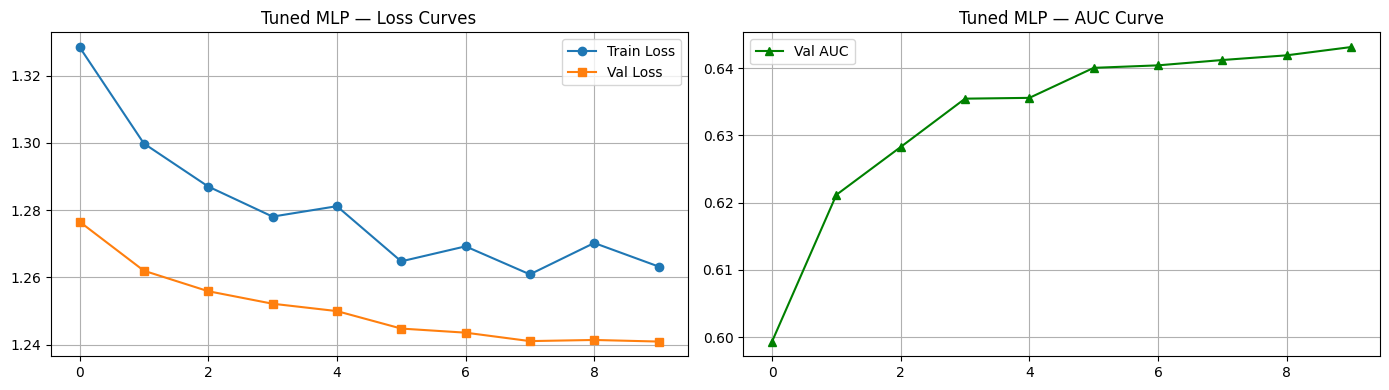

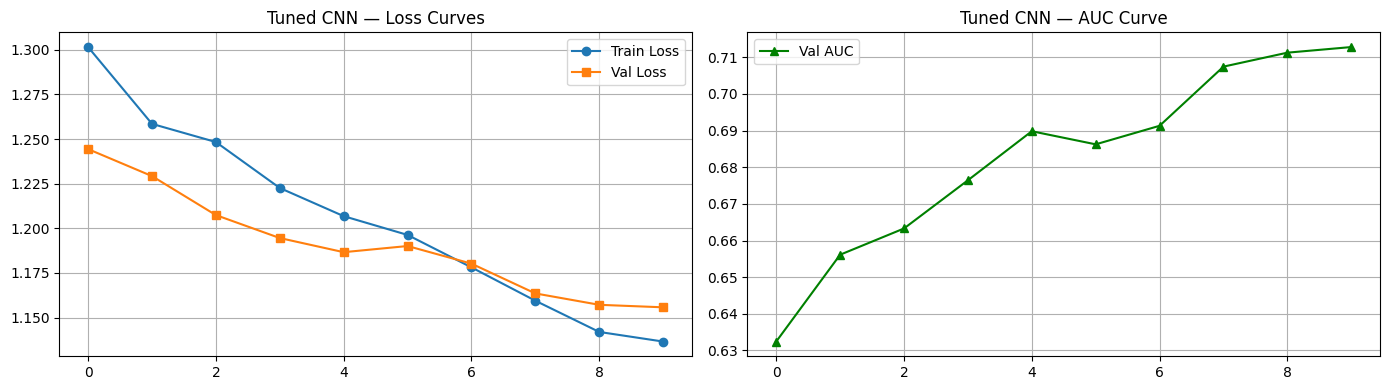

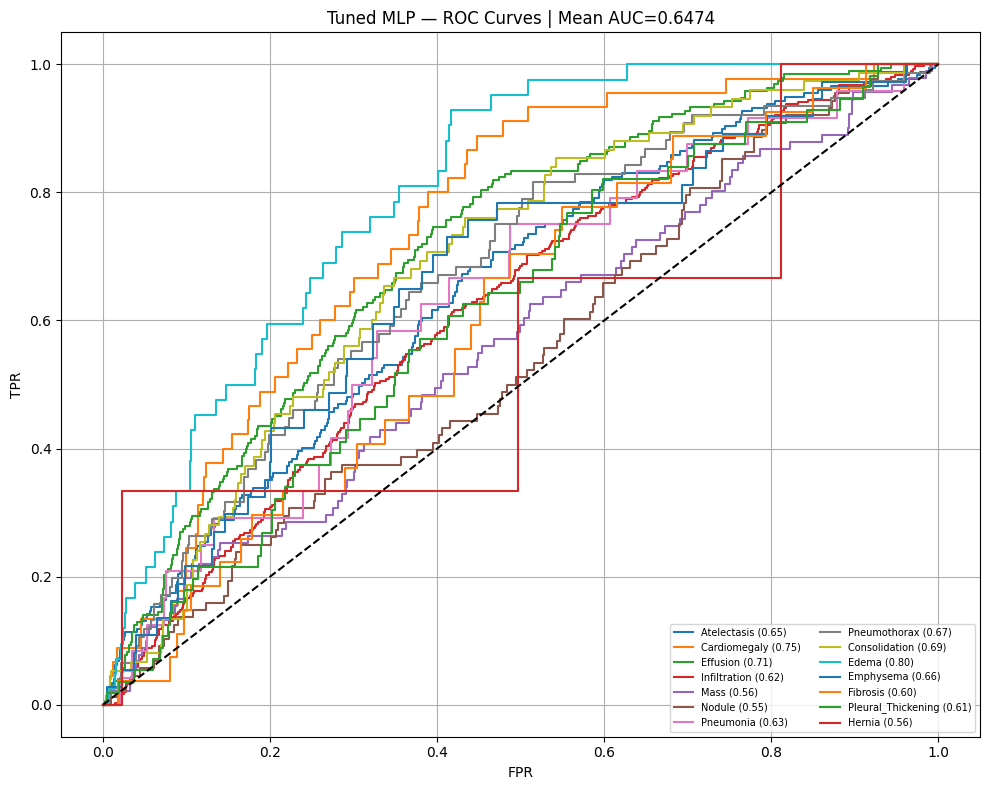

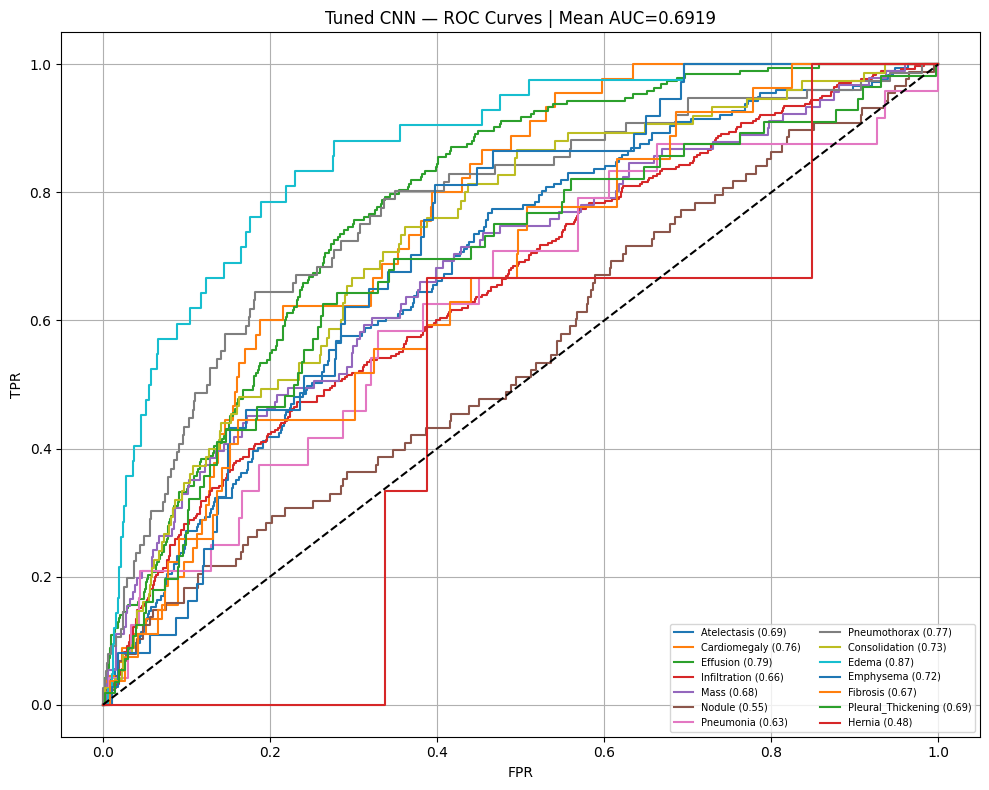

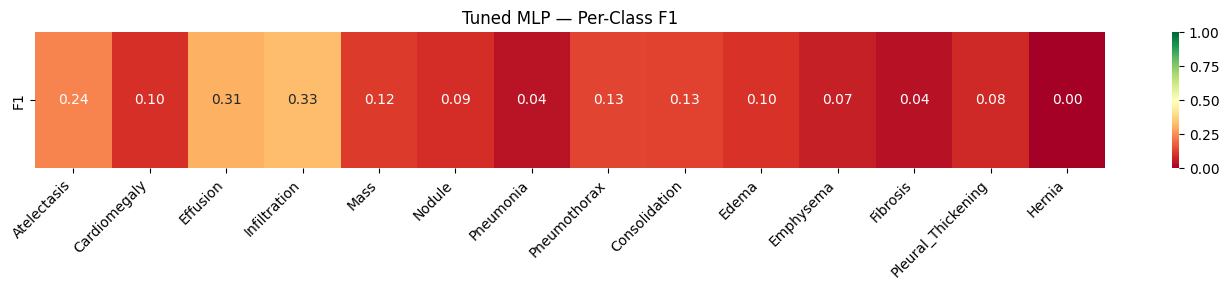

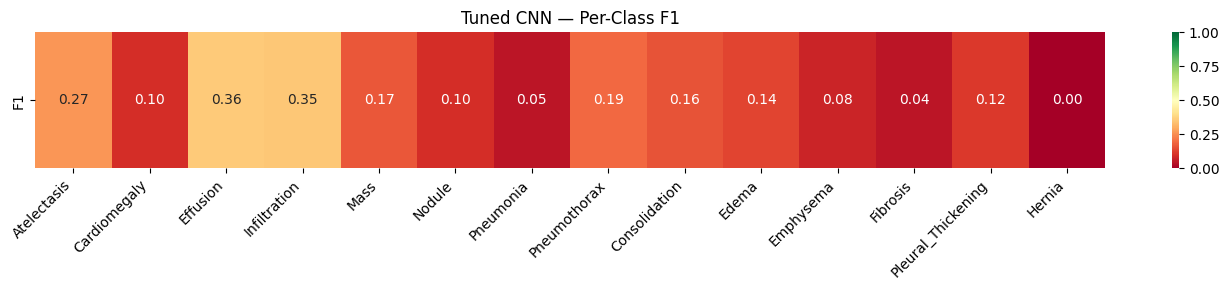

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_auc_score, roc_curve, f1_score

def plot_learning_curves(history, title=''):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
    ax1.plot(history['train_loss'], label='Train Loss', marker='o')
    ax1.plot(history['val_loss'],   label='Val Loss',   marker='s')
    ax1.set_title(f'{title} — Loss Curves'); ax1.legend(); ax1.grid(True)
    ax2.plot(history['val_auc'], color='green', marker='^', label='Val AUC')
    ax2.set_title(f'{title} — AUC Curve'); ax2.legend(); ax2.grid(True)
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, f'curves_{title.replace(" ","_")}.png'), dpi=100)
    plt.show()

def plot_roc_curves(y_true, y_scores, title='', classes=CLASSES):
    fig, ax = plt.subplots(figsize=(10, 8))
    aucs = []
    for i, cls in enumerate(classes):
        try:
            auc = roc_auc_score(y_true[:,i], y_scores[:,i])
            fpr, tpr, _ = roc_curve(y_true[:,i], y_scores[:,i])
            ax.plot(fpr, tpr, lw=1.5, label=f'{cls} ({auc:.2f})')
            aucs.append(auc)
        except: aucs.append(0.5)
    ax.plot([0,1],[0,1],'k--'); ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
    ax.set_title(f'{title} — ROC Curves | Mean AUC={np.mean(aucs):.4f}')
    ax.legend(fontsize=7, ncol=2, loc='lower right'); ax.grid(True)
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, f'roc_{title.replace(" ","_")}.png'), dpi=100)
    plt.show()
    return aucs

def evaluate_model(model, loader):
    model.eval()
    all_y, all_p = [], []
    with torch.no_grad():
        for imgs, lbls in loader:
            p = torch.sigmoid(model(imgs.to(DEVICE)))
            all_y.append(lbls.numpy()); all_p.append(p.cpu().numpy())
    return np.concatenate(all_y), np.concatenate(all_p)

# Plot curves for both models
for name, res in final_results.items():
    plot_learning_curves(res['history'], title=name)

# ROC + AUC
for name, res in final_results.items():
    y, p = evaluate_model(res['model'], test_loader_final)
    aucs = plot_roc_curves(y, p, title=name)
    res['per_class_auc'] = dict(zip(CLASSES, aucs))

# Per-class F1 heatmap
def per_class_f1_heatmap(model, loader, title=''):
    y, p = evaluate_model(model, loader)
    y_pred = (p > 0.5).astype(int)
    f1s = [f1_score(y[:,i], y_pred[:,i], zero_division=0) for i in range(NUM_CLASSES)]
    plt.figure(figsize=(14, 3))
    sns.heatmap(np.array(f1s).reshape(1,-1), annot=True, fmt='.2f',
                xticklabels=CLASSES, yticklabels=['F1'], cmap='RdYlGn', vmin=0, vmax=1)
    plt.title(f'{title} — Per-Class F1'); plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, f'f1_{title.replace(" ","_")}.png'), dpi=100)
    plt.show()

for name, res in final_results.items():
    per_class_f1_heatmap(res['model'], test_loader_final, title=name)


## Section 6 — Comparative Analysis: MLP vs CNN


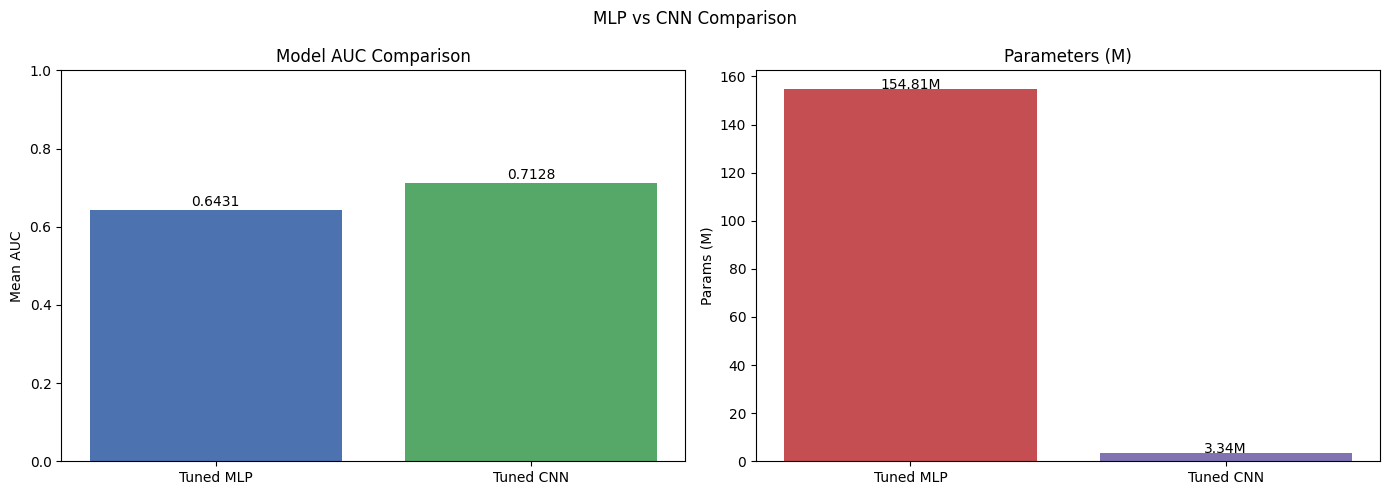


Model                     AUC          Params
---------------------------------------------
Tuned MLP              0.6431     154,805,006
Tuned CNN              0.7128       3,339,374

--- Bias-Variance ---
  Tuned MLP: train_loss=1.2632 val_loss=1.2409 gap=-0.0223 → UNDERFITTING
  Tuned CNN: train_loss=1.1366 val_loss=1.1557 gap=0.0192 → UNDERFITTING


In [14]:
names = list(final_results.keys())
aucs  = [final_results[n]['auc'] for n in names]
nparams = [final_results[n]['n_params'] for n in names]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(names, aucs, color=['#4C72B0','#55A868'])
axes[0].set_title('Model AUC Comparison'); axes[0].set_ylabel('Mean AUC'); axes[0].set_ylim(0, 1)
for i,v in enumerate(aucs): axes[0].text(i, v+0.01, f'{v:.4f}', ha='center')
pm = [p/1e6 for p in nparams]
axes[1].bar(names, pm, color=['#C44E52','#8172B2'])
axes[1].set_title('Parameters (M)'); axes[1].set_ylabel('Params (M)')
for i,v in enumerate(pm): axes[1].text(i, v+0.01, f'{v:.2f}M', ha='center')
plt.suptitle('MLP vs CNN Comparison'); plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'comparison.png'), dpi=100); plt.show()

print(f'\n{"Model":<20} {"AUC":>8} {"Params":>15}')
print('-'*45)
for n,a,p in zip(names,aucs,nparams):
    print(f'{n:<20} {a:>8.4f} {p:>15,}')

# Bias-variance
print('\n--- Bias-Variance ---')
for name in names:
    h = final_results[name]['history']
    gap = h['val_loss'][-1] - h['train_loss'][-1]
    verdict = 'OVERFITTING' if gap>0.05 else ('UNDERFITTING' if h['train_loss'][-1]>0.4 else 'GOOD FIT')
    print(f'  {name}: train_loss={h["train_loss"][-1]:.4f} val_loss={h["val_loss"][-1]:.4f} gap={gap:.4f} → {verdict}')


## Grad-CAM Explainability


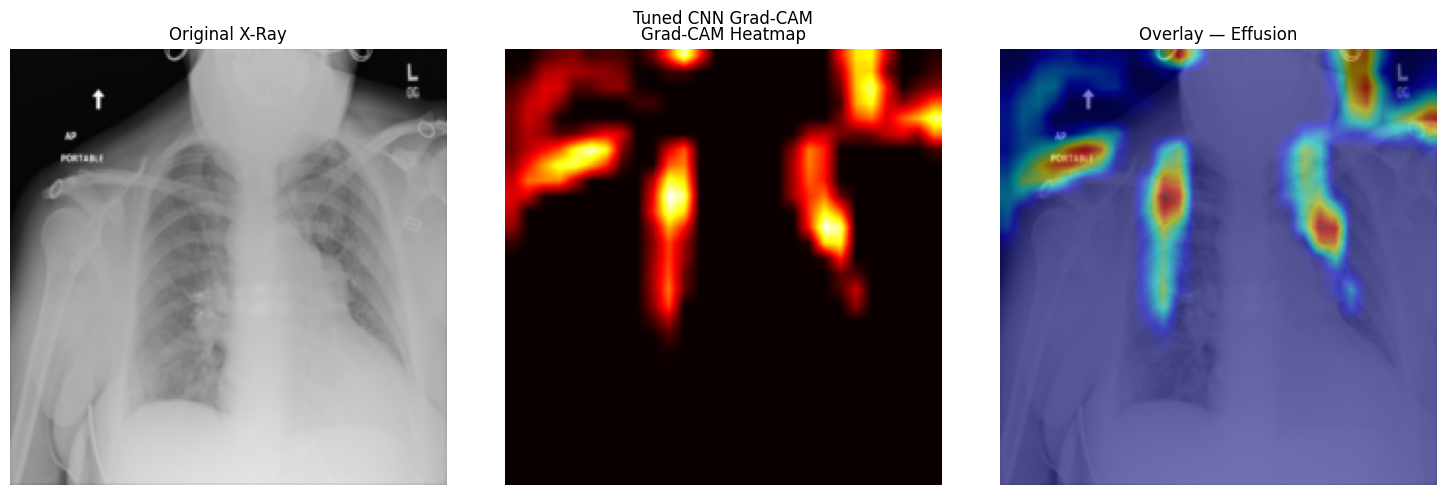

In [18]:
import cv2

class GradCAM:
    def __init__(self, model, layer):
        self.model, self.activations, self.gradients = model, None, None
        layer.register_forward_hook(lambda m,i,o: setattr(self,'activations',o.clone()))
        layer.register_full_backward_hook(lambda m,gi,go: setattr(self,'gradients',go[0]))
    
    def __call__(self, x, cls_idx=None):
        self.model.zero_grad()
        out = self.model(x)
        if cls_idx is None: 
            cls_idx = out[0].argmax().item()
        t = torch.zeros_like(out)
        t[0,cls_idx] = 1
        out.backward(gradient=t, retain_graph=True)
        w = self.gradients.mean(dim=[0,2,3])
        cam = (self.activations[0] * w[:,None,None]).mean(0)
        cam = np.maximum(cam.cpu().detach().numpy(), 0)
        cam = cv2.resize(cam, IMG_SIZE)
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam

def show_gradcam(model, loader, cls_idx=0, title='CNN'):
    model.eval()
    
    # Disable inplace operations temporarily
    def set_inplace(module, inplace_val):
        for child in module.modules():
            if isinstance(child, nn.ReLU):
                child.inplace = inplace_val
    
    set_inplace(model, False)  # Disable inplace
    
    try:
        imgs, _ = next(iter(loader))
        img_t = imgs[0:1].to(DEVICE).requires_grad_(True)
        
        # Use last conv layer
        if hasattr(model, 'features'):
            target_layer = list(model.features.children())[-1].block[-3]  # last conv
        else:
            return  # MLP doesn't have conv layers
        
        cam = GradCAM(model, target_layer)(img_t, cls_idx=cls_idx)
        
        # Denormalize
        mean = np.array([0.485,0.456,0.406])
        std = np.array([0.229,0.224,0.225])
        img_np = imgs[0].permute(1,2,0).numpy()*std + mean
        img_np = np.clip(img_np, 0, 1)
        
        heatmap = cv2.applyColorMap((cam*255).astype(np.uint8), cv2.COLORMAP_JET)
        heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB) / 255.0
        overlay = 0.5*img_np + 0.5*heatmap
        
        fig, axes = plt.subplots(1, 3, figsize=(15, 5))
        axes[0].imshow(img_np); axes[0].set_title('Original X-Ray')
        axes[1].imshow(cam, cmap='hot'); axes[1].set_title('Grad-CAM Heatmap')
        axes[2].imshow(overlay); axes[2].set_title(f'Overlay — {CLASSES[cls_idx]}')
        for ax in axes: ax.axis('off')
        plt.suptitle(f'{title} Grad-CAM'); plt.tight_layout()
        plt.savefig(os.path.join(OUT_DIR, f'gradcam_{title.replace(" ","_")}.png'), dpi=100)
        plt.show()
    
    finally:
        set_inplace(model, True)  # Re-enable inplace

show_gradcam(cnn_model, test_loader_final, cls_idx=2, title='Tuned CNN')

## Model Saving — All Formats (UI-Ready)


In [19]:
# ============================================================
# MODEL SAVING — PyTorch + ONNX + Metadata
# All files saved to /kaggle/working/models_r1/
# ============================================================

def save_model_full(model, name, val_auc, params):
    base = os.path.join(MODEL_DIR, name.replace(' ','_'))

    # 1. Full checkpoint (for resuming training)
    torch.save({
        'model_class': type(model).__name__,
        'state_dict': model.state_dict(),
        'val_auc': val_auc,
        'params': params,
        'classes': CLASSES,
        'img_size': IMG_SIZE,
        'n_params': sum(p.numel() for p in model.parameters())
    }, f'{base}_checkpoint.pth')

    # 2. Weights-only (for UI/inference)
    torch.save(model.state_dict(), f'{base}_weights.pth')

    # 3. ONNX export (for fast inference / FastAPI backend)
    model.eval()
    dummy = torch.randn(1, 3, IMG_SIZE[0], IMG_SIZE[1]).to(DEVICE)
    try:
        torch.onnx.export(
            model, dummy, f'{base}.onnx',
            input_names=['input'], output_names=['output'],
            dynamic_axes={'input':{0:'batch_size'},'output':{0:'batch_size'}},
            opset_version=11)
        print(f'  ONNX → {base}.onnx')
    except Exception as e:
        print(f'  ONNX skipped: {e}')

    print(f'  Checkpoint → {base}_checkpoint.pth')
    print(f'  Weights    → {base}_weights.pth')
    return f'{base}_checkpoint.pth'

# Save all models
saved = {}
for name, res in final_results.items():
    print(f'\nSaving {name}...')
    path = save_model_full(res['model'], name, res['auc'], res['params'])
    saved[name] = path

# Save combined results CSV
csv_rows = []
for name, res in final_results.items():
    row = {'model': name, 'mean_auc': res['auc'], 'n_params': res['n_params']}
    row.update({f'auc_{c}': res.get('per_class_auc',{}).get(c, 0) for c in CLASSES})
    csv_rows.append(row)
pd.DataFrame(csv_rows).to_csv(os.path.join(OUT_DIR,'review1_results.csv'), index=False)

# Print summary
print('\n' + '='*60)
print('  REVIEW 1 — ALL MODELS SAVED')
print('='*60)
for name, path in saved.items():
    print(f'  {name}: {path}')
print(f'\n  Results CSV → {OUT_DIR}/review1_results.csv')
print(f'  Figures     → {OUT_DIR}/*.png')



Saving Tuned MLP...
  ONNX skipped: No module named 'onnxscript'
  Checkpoint → /kaggle/working/models_r1/Tuned_MLP_checkpoint.pth
  Weights    → /kaggle/working/models_r1/Tuned_MLP_weights.pth

Saving Tuned CNN...
  ONNX skipped: No module named 'onnxscript'
  Checkpoint → /kaggle/working/models_r1/Tuned_CNN_checkpoint.pth
  Weights    → /kaggle/working/models_r1/Tuned_CNN_weights.pth

  REVIEW 1 — ALL MODELS SAVED
  Tuned MLP: /kaggle/working/models_r1/Tuned_MLP_checkpoint.pth
  Tuned CNN: /kaggle/working/models_r1/Tuned_CNN_checkpoint.pth

  Results CSV → /kaggle/working/review1_results.csv
  Figures     → /kaggle/working/*.png
